In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

In [2]:
image_generator = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.1,
    zoom_range=0.3,
)
# For test data we should not data augmentations
image_generator_test = ImageDataGenerator(rescale=1. / 255)

In [3]:
train_data = image_generator.flow_from_directory(
    'data',
    target_size=(500, 500),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=50
)

Found 550 images belonging to 2 classes.


In [6]:
test_data = image_generator_test.flow_from_directory(
    'test_data',
    target_size=(500, 500),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=50
)

Found 74 images belonging to 2 classes.


In [7]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(500, 500, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

/home/lucifer666/anaconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-23 15:07:38.207986: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
plot_model(model, show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [12]:
compute_class_weight(class_weight='balanced', classes=np.unique(train_data.classes), y=train_data.classes)

array([1.39593909, 0.77903683])

In [14]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_data.classes), y=train_data.classes)

In [17]:
class_weights = dict(zip(np.unique(train_data.classes), weights))
class_weights

{np.int32(0): np.float64(1.3959390862944163),
 np.int32(1): np.float64(0.7790368271954674)}

In [18]:
class_weights = {
    int(k): float(v)
    for k, v in zip(np.unique(train_data.classes), weights)
}

print(class_weights)

{0: 1.3959390862944163, 1: 0.7790368271954674}


In [ ]:
ES = EarlyStopping(monitor='val_loss', mode='min', patience=8)
RLROP = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.2, min_lr=0.001)

In [22]:
MCH = ModelCheckpoint('./model/chestxray.h5', monitor='val_loss', mode='min', save_best_only=True)

In [ ]:
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    epochs=50,
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[ES, RLROP, MCH],
    class_weight=class_weights
)

In [ ]:
history.history()

In [ ]:
plt.plot(history.history['accuracy'], color='green')
plt.plot(history.history['val_accuracy'], color='blue')

In [ ]:
plt.plot(history.history['loss'], color='green')
plt.plot(history.history['val_loss'], color='blue')

In [23]:
# -------------------------- Restart Kernel

In [24]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

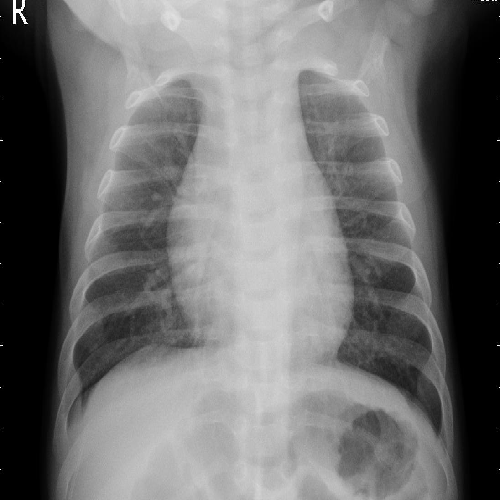

In [27]:
img = load_img('./test_data/opacity/person1653_virus_2859.jpeg', target_size=(500, 500, 1), color_mode='grayscale')
img

In [28]:
img = img_to_array(img)
img

array([[[16.],
        [17.],
        [18.],
        ...,
        [ 0.],
        [ 6.],
        [ 5.]],

       [[16.],
        [16.],
        [17.],
        ...,
        [21.],
        [ 3.],
        [ 0.]],

       [[15.],
        [16.],
        [17.],
        ...,
        [ 4.],
        [21.],
        [ 0.]],

       ...,

       [[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]],

       [[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]],

       [[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]]], shape=(500, 500, 1), dtype=float32)

In [ ]:
model = load_model('./data/chestxray.h5')
model.summary()

In [ ]:
import tensorflow as tf
pred = model.predict(tf.expand_dims(img, axis=0))
pred

In [ ]:
if float(pred[0][0]) > 0.5:
    print('The patient has virus')
else:
    print('The patient has not virus')